In [75]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys 
import os
import seaborn as sns
sys.path.append("../eyeprep/utils")
from eyetrack_utils import (
    load_event_files,              # Load EyeLink event files
    extract_data,                  # Extract data from raw files
    blinkrm_pupil_off,             # Remove blinks with direct pupil detection
    blinkrm_pupil_off_smooth,      # Remove blinks with pupil detection and gaussian kernel 
    interpol_nans,                 # Interpolate missing values
    detrending,                    # Remove trends from signal
    downsample_to_targetrate,      # Change sampling rate
    moving_average_smoothing,      # Smooth with moving average
    gaussian_smoothing,            # Smooth with Gaussian kernel
    extract_eye_data_and_triggers, # Extract gaze and trial timing
    convert_to_dva                 # Convert to degrees of visual angle
)
from settings_utils import load_settings        # Load yml settings function 

What do we put in the QC report?
- length of run (check missing time samples)
- proportion of missing data / blinks. Hist of blink durations, inter-blink interval
- plot of full display and 2D coords
- plot all 3 traces

In [7]:
def pandoc_md2html(mdP, embed=True):
    htmlP = mdP.replace('.md', '.html')
    cmd = 'pandoc %s -o %s'%(mdP, htmlP)
    if embed: cmd += ' --self-contained ' #2.18
    return cmd

In [11]:
# Define experiment parameters and load configuration settings


EYEPREP_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
main_dir = os.path.abspath(os.getcwd())
project_dir = "data"
subject = "sub-01"
task = "SacLoc"  # Saccade localization task

# get settings 
general_settings_path = os.path.abspath(os.path.join(main_dir, "../eye-tracking.yml"))
task_settings_path = os.path.abspath(os.path.join(main_dir, f"../eye-tracking_{task}.yml"))
settings = load_settings([general_settings_path, task_settings_path])
analysis_info = settings[0]

ses = analysis_info["session"]
eye = analysis_info["eye"]


In [12]:
def extract_event_and_physio_data(main_dir, project_dir, subject, task, ses, num_run, eye):
    """
    Extract both event timing and physiological data from raw eye tracking files.
    
    Parameters:
    -----------
    main_dir : str
        Root directory containing all study data
    project_dir : str
        Project-specific subdirectory
    subject : str
        Subject ID (e.g., 'sub-01')
    task : str
        Task name (e.g., 'SacLoc' for saccade localization)
    ses : str
        Session ID (e.g., 'ses-01')
    num_run : int
        Number of runs to load
    eye : str
        Which eye to analyze ('eye1' or 'eye2')
    
    Returns:
    --------
    df_event_runs : list of DataFrames
        Event timing data (trial onsets, offsets, etc.)
    df_data_runs : list of DataFrames
        Raw physiological data (gaze position, pupil size, timestamps)
    """
    df_event_runs = extract_data(main_dir, project_dir, subject, task, ses, num_run, eye, file_type="physioevents") # check utils to find this function! 
    df_data_runs = extract_data(main_dir, project_dir, subject, task, ses, num_run, eye, file_type="physio")
    return df_event_runs, df_data_runs

In [26]:
[df_event_runs, _], [df_data_runs, df_name_runs] = extract_event_and_physio_data(
    main_dir, project_dir, subject, task, ses, 
    analysis_info['num_run'], eye
)

print(f"Loaded {len(df_data_runs)} runs of eye tracking data")
print(f"Data is stored in a list, each run is one element. Lets look at the data from run 1:")
print(df_data_runs[0].head())


Loaded 2 runs of eye tracking data
Data is stored in a list, each run is one element. Lets look at the data from run 1:
   timestamp  x_coordinate  y_coordinate  pupil_size
0   13084637        1032.7         563.2      9087.0
1   13084638        1040.2         562.4      9083.0
2   13084639        1055.1         560.1      9080.0
3   13084640        1055.8         560.0      9078.0
4   13084641        1058.7         576.7      9077.0


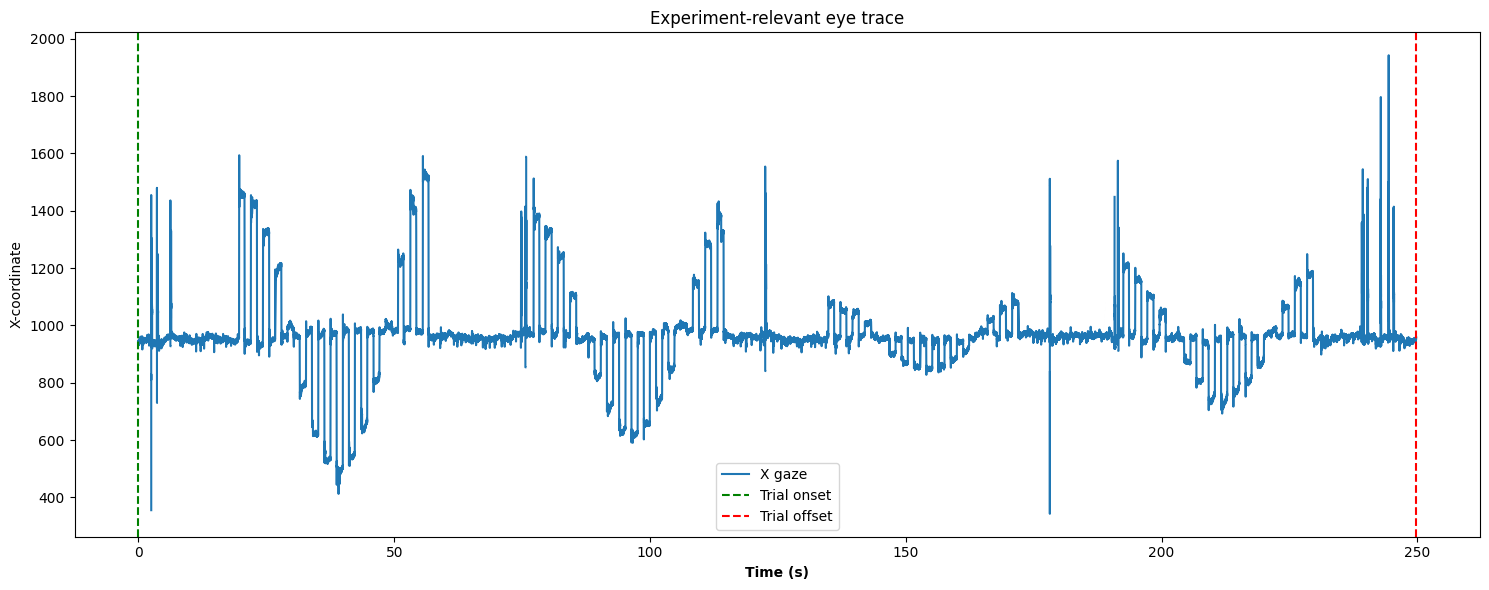

Recording duration: 335.3 seconds
First trial onset at: 81.379


In [27]:
# Align eye tracking data with experimental trial timing

# Extract gaze data and trial trigger times
eye_data_run, time_start_eye, time_end_eye = extract_eye_data_and_triggers(
    df_event_runs[0], 
    df_data_runs[0],
    analysis_info['first_trial_pattern'], 
    analysis_info['last_trial_pattern']
)

# Convert timestamps to seconds (easier to work with than milliseconds)
eye_times = (df_data_runs[0]['timestamp'] - df_data_runs[0]['timestamp'][0]) * 1e-3
eye_times = eye_times.to_numpy()

# Convert trial onset times to seconds relative to first eye sample
trial_onsets_sec = (time_start_eye - df_data_runs[0]['timestamp'][0]) * 1e-3

print(f"Recording duration: {eye_times[-1]:.1f} seconds")
print(f"First trial onset at: {(trial_onsets_sec)}")


In [23]:
np.unique(np.diff(df_data_runs[0]['timestamp']))
analysis_info['eyetrack_sampling']

1000

In [32]:
def remove_blinks(data, method, sampling_rate):
    """
    Remove blink artifacts from eye tracking data.
    
    Blinks cause temporary invalid gaze measurements. We remove them by either:
    - pupil_off: Replace blink periods with NaN (pupil disappears during blinks)
    - pupil_off_smooth: Replace and smooth the transition
    
    Parameters:
    -----------
    data : ndarray
        Eye tracking data array
    method : str
        Which blink removal method to use
    sampling_rate : int
        Eye tracker sampling rate (Hz, e.g., 500)
    
    Returns:
    --------
    data : ndarray
        Data with blinks removed (replaced with NaN or smoothed)
    """
    if method == 'pupil_off':
        return blinkrm_pupil_off(data, sampling_rate)
    elif method == 'pupil_off_smooth':
        return blinkrm_pupil_off_smooth(data, sampling_rate)
    else:
        print("Warning: No blink removal method specified. Returning original data.")
        return data


def drift_correction(data, method, fixation_periods):
    """
    Correct for eye tracker drift over time.
    
    Eye trackers lose calibration during recording, causing the measured gaze
    position to drift. We correct this by:
    - linear: Fit a line and remove the trend
    - median: Use median gaze position during fixations as reference
    
    Parameters:
    -----------
    data : ndarray
        Eye tracking data
    method : str
        Drift correction method ('linear' or 'median')
    fixation_periods : list
        Time indices of known fixations (for median method)
    
    Returns:
    --------
    data : ndarray
        Drift-corrected data
    """
    if method == "linear":
        return detrending(data, type='linear')
    elif method == 'median':
        fixation_median = np.median([item for row in fixation_periods for item in row])
        return np.array([elem - fixation_median for elem in data])
    else:
        print("Warning: No drift correction method specified. Returning original data.")
        return data


def interpolate_nans(data):
    """
    Fill in missing data points (NaN values).
    
    After removing blinks, we have gaps in our data. Linear interpolation
    estimates the missing values based on surrounding data points.
    
    Parameters:
    -----------
    data : ndarray
        Data with NaN values
    
    Returns:
    --------
    data : ndarray
        Data with NaN values interpolated
    """
    return interpol_nans(data)


def normalize_data(data):
    """
    Normalize pupil size to a standard range.
    
    Pupil size varies across subjects and sessions due to lighting conditions
    and individual differences. Normalization (scaling) makes data comparable.
    
    We scale to [-1, 1] so that values are centered at 0 with equal ranges
    on both sides (useful for neural networks and other ML methods).
    
    Parameters:
    -----------
    data : ndarray
        Raw pupil size data
    
    Returns:
    --------
    data : ndarray
        Normalized pupil size
    """
    print('- normalizing pupil data to [-1, 1]')
    scaler = MinMaxScaler(feature_range=(-1, 1))
    return scaler.fit_transform(data.reshape(-1, 1)).flatten()

- blink replacement with NaN


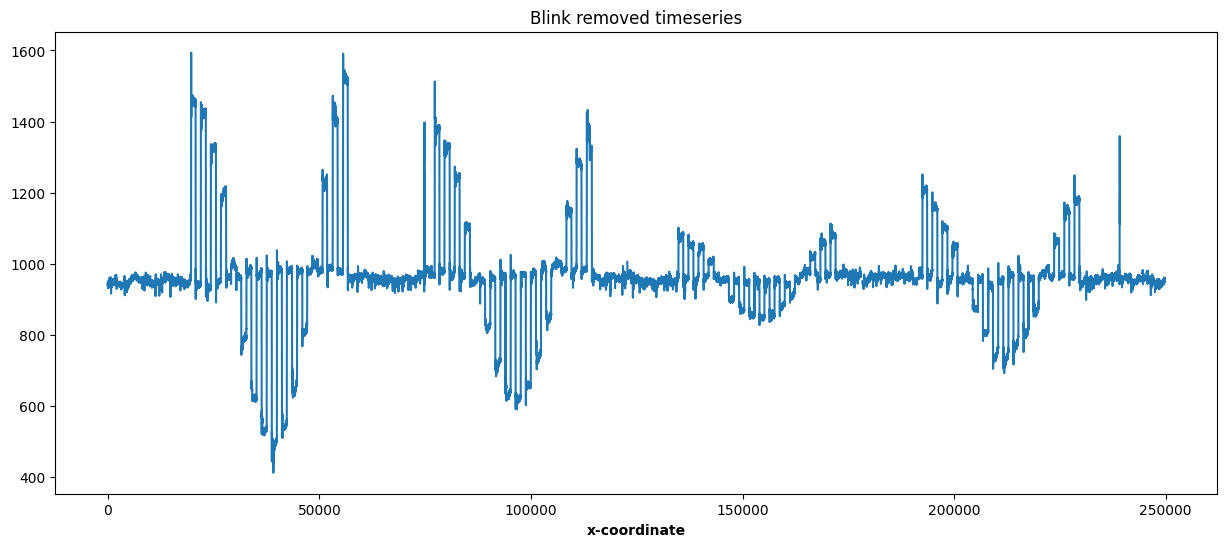

✓ Blinks removed


In [33]:
# STEP 1: Remove blinks
# Blinks cause the pupil to disappear and gaze data to be unreliable
eye_data_run_blinks = remove_blinks(
    eye_data_run, 
    analysis_info['blinks_remove'],      # Method specified in config
    analysis_info['eyetrack_sampling']   # Sampling rate (Hz)
)
print("✓ Blinks removed")

In [52]:
# Step 2: Convert to dva 
# Transform from pixel coordinates to a viewer-independent measure: Dva ~ rotation angle of the eye 
# attention: run this only once ;)
eye_data_run_dva = convert_to_dva(eye_data_run_blinks, analysis_info['center'], analysis_info['ppd'])

print("Lets have a look at our gaze on the screen now. Run the next cell to see!")

Lets have a look at our gaze on the screen now. Run the next cell to see!


In [169]:
is_nan = np.logical_or(np.isnan(eye_data_run_dva[:, 1]), np.isnan(eye_data_run_dva[:, 2]))
print(np.mean(is_nan))

sampling_frequency = analysis_info['eyetrack_sampling'] #Hz

# Find start and end of NaN runs
diff = np.diff(is_nan.astype(int))
starts = np.where(diff == 1)[0] + 1
ends   = np.where(diff == -1)[0] + 1

# Handle edge cases
if is_nan[0]:
    starts = np.r_[0, starts]
if is_nan[-1]:
    ends = np.r_[ends, len(arr)]

# Durations of NaNs
durations = ends - starts
print(durations/sampling_frequency, "s", len(durations), "blinks")

# Gaps between NaN runs
durations_between_nans = starts[1:] - ends[:-1]
print(durations_between_nans/sampling_frequency, "s")

0.02100816784112748
[0.406 0.418 0.415 0.451 0.396 0.386 0.351 0.419 0.426 0.431 0.353 0.401
 0.394] s 13 blinks
[ 0.713  2.207 68.979 46.426 55.248 12.262  0.302 47.451  0.424  2.183
  1.141  0.61 ] s


In [107]:
res_x_px, res_y_px = [x*2 for x in analysis_info['center']]
res_x_dva = res_x_px/analysis_info['ppd']
res_y_dva = res_y_px/analysis_info['ppd']
print(res_x_dva, res_y_dva)

idx_outOfRange = np.logical_or(np.abs(eye_data_run_dva[:, 1]) >= res_x_dva/2,
np.abs(eye_data_run_dva[:, 2]) >= res_y_dva/2) 

prop_outOfRange = np.mean(np.logical_or(np.abs(eye_data_run_dva[:, 1]) >= res_x_dva/2,
np.abs(eye_data_run_dva[:, 2]) >= res_y_dva/2))

36.922850335207926 20.769103313554456


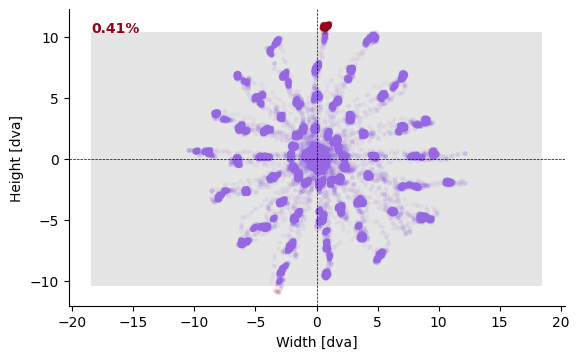

In [166]:
f, ax = plt.subplots()

#ax.set_xlim((-res_x_dva/2, +res_x_dva/2))
#ax.set_ylim((-res_y_dva/2, +res_y_dva/2))

c1 = '#9667E0'
c2 = '#96031a'

ax.plot(eye_data_run_dva[~idx_outOfRange, 1], eye_data_run_dva[~idx_outOfRange, 2], '.', alpha=0.05, ms=5, color=c1)
ax.plot(eye_data_run_dva[idx_outOfRange, 1], eye_data_run_dva[idx_outOfRange, 2], '.', alpha=0.05, ms=5, color=c2)

ax.set_aspect('equal')

rect = plt.Rectangle(
    (-res_x_dva/2, -res_y_dva/2),   # bottom-left (x, y)
    res_x_dva,        # width
    res_y_dva,        # height
    facecolor='grey',
    edgecolor='None',
    alpha=0.2
)
ax.add_patch(rect)
ax.axhline(y=0, ls='--', lw=0.5, color='k')
ax.axvline(x=0, ls='--', lw=0.5, color='k')

ax.set_xlabel('Width [dva]')
ax.set_ylabel('Height [dva]')

ax.text(-res_x_dva/2, +res_y_dva/2,
    "%3.2f%%"%(prop_outOfRange*100), color=c2, fontweight='bold')
sns.despine()

In [167]:
f.savefig('/Users/marianne/Downloads/gaze2Dscatter.png',
         bbox_inches='tight')

In [125]:
blink_starts_s = starts/sampling_frequency
blink_ends_s = ends/sampling_frequency

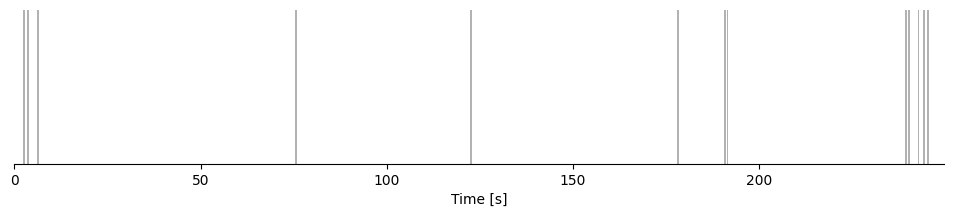

In [146]:
f, ax = plt.subplots(figsize=(12, 2))
ax.set_xlim((0, eye_data_run_dva.shape[0]/sampling_frequency))
#ax.set_ylim((-res_y_dva/2, +res_y_dva/2))
for b in range(len(blink_starts_s)):
    rect = plt.Rectangle(
        (blink_starts_s[b], 0),   # bottom-left (x, y)
        durations[b]/sampling_frequency,        # width
        1,        # height
        facecolor='black',
        edgecolor='None',
        alpha=0.3
    )
    ax.add_patch(rect)
sns.despine()
ax.set_yticks([])        # remove tick marks
ax.set_yticklabels([])   # remove tick labels
ax.spines['left'].set_visible(False)  
ax.set_xlabel('Time [s]')
f.savefig('/Users/marianne/Downloads/blinks.png',
         bbox_inches='tight')